In [1]:
# Step 1: Setup & Import
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

sns.set_theme(style="whitegrid")

In [2]:
# Step 2: Load Dataset
df = pd.read_csv("StudentPerformanceFactors.csv")

print("--- Dataset Preview ---")
print(df.head())

--- Dataset Preview ---
   Id  Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0   1             23          84                  Low                High   
1   2             19          64                  Low              Medium   
2   3             24          98               Medium              Medium   
3   4             29          89                  Low              Medium   
4   5             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions F

In [3]:
# Step 3: Correlation Analysis

# Relationship with Exam Score (target variable)

# Select important numerical columns
num_cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours',
            'Previous_Scores', 'Tutoring_Sessions',
            'Physical_Activity', 'Exam_Score']

corr_matrix = df[num_cols].corr()

print("\n--- STEP 3: CORRELATION COEFFICIENTS ---")
print(corr_matrix['Exam_Score'].sort_values(ascending=False).round(4))


--- STEP 3: CORRELATION COEFFICIENTS ---
Exam_Score           1.0000
Attendance           0.5521
Hours_Studied        0.4205
Previous_Scores      0.1672
Tutoring_Sessions    0.1434
Physical_Activity    0.0279
Sleep_Hours         -0.0145
Name: Exam_Score, dtype: float64


In [4]:
# Step 4: Regression Modeling

#Predict Exam Score using key factors
# Features (independent variables)
X = df[['Hours_Studied', 'Attendance', 'Previous_Scores']]

# Target variable
Y = df['Exam_Score']

# Model
model = LinearRegression()
model.fit(X, Y)

# Parameters
coefficients = model.coef_
intercept = model.intercept_
r_sq = model.score(X, Y)

print("\n--- STEP 4: REGRESSION PARAMETERS ---")
print(f"Coefficients (m): {coefficients}")
print(f"Intercept (c): {intercept}")
print(f"R-Squared (Accuracy): {round(r_sq,4)}")


--- STEP 4: REGRESSION PARAMETERS ---
Coefficients (m): [0.28793756 0.198188   0.04772242]
Intercept (c): 42.00533644740135
R-Squared (Accuracy): 0.5145


In [5]:
# Step 5: Prediction

# Predict score for a new student
# Example input:
# Hours_Studied=10, Attendance=85, Previous_Scores=75
new_input = np.array([[10, 85, 75]])

prediction = model.predict(new_input)

print("\n--- STEP 5: PREDICTION ---")
print(f"Predicted Exam Score: {prediction[0].round(2)}")


--- STEP 5: PREDICTION ---
Predicted Exam Score: 65.31


C:\Users\nidhi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


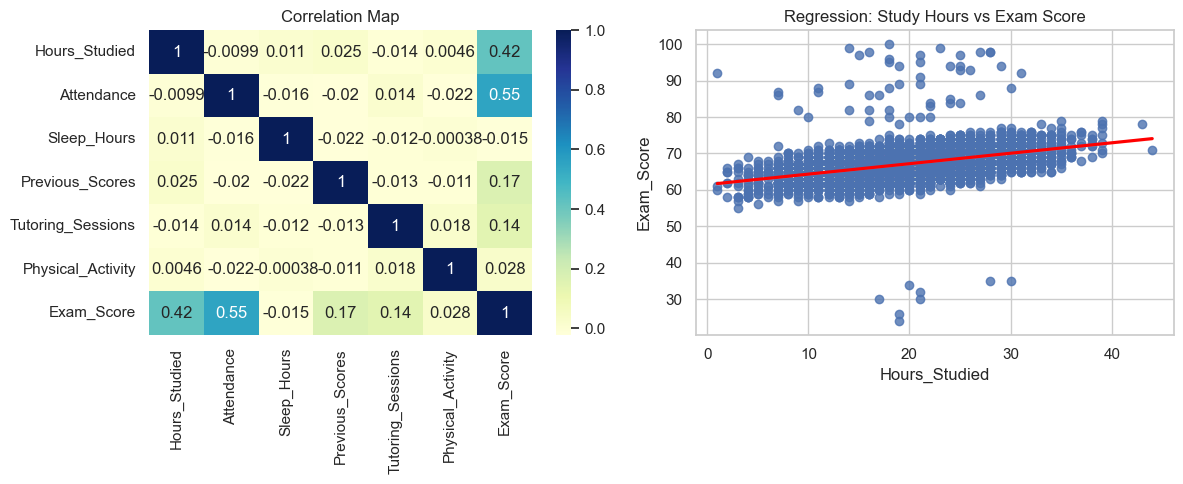

In [6]:
# Step 6: Visualization
# Correlation Heatmap + Regression Plot
plt.figure(figsize=(12, 5))

# Heatmap
plt.subplot(1, 2, 1)
sns.heatmap(corr_matrix, annot=True, cmap='YlGnBu')
plt.title("Correlation Map")

# Regression Plot (Single variable visualization)
plt.subplot(1, 2, 2)
sns.regplot(x='Hours_Studied', y='Exam_Score',
            data=df, line_kws={"color": "red"})

plt.title("Regression: Study Hours vs Exam Score")

plt.tight_layout()
plt.show()